# Phase 2 — Microtiming Deviation Analysis

Following beat and onset extraction in Phase 1, we now quantify Herbie Hancock's expressive timing by measuring the temporal deviations between performed note onsets and the estimated beat grid.

Rather than treating rhythm as perfectly quantized, this phase investigates **microtiming**, i.e., the intentional millisecond-scale timing variations that contribute to groove and expressive performance.

The resulting deviation distributions will later serve as the statistical foundation for the Groove Profile model developed in Phase 3.

## Research Question (RQ1)

How does Herbie Hancock's microtiming behavior evolve across different stylistic periods?

Specifically:

- Does he systematically play ahead of or behind the beat?
- Does the variability of his timing increase or decrease over time?
- Can these stylistic differences be quantified statistically using Music Information Retrieval techniques?

## Methodology

The onset positions extracted during Phase 1 are aligned to the nearest beat location estimated using dynamic beat tracking.

For every detected onset $t_i$, the nearest beat location $b_j$ is identified and the timing deviation is computed as

$$
\Delta t_i = t_i - b_j
$$

where

- $\Delta t > 0$ indicates **behind-the-beat** performance (dragging);
- $\Delta t < 0$ indicates **ahead-of-the-beat** performance (rushing).

Only deviations within **±80 ms** are retained.

This threshold excludes syncopated notes that belong to different metric subdivisions rather than expressive microtiming deviations.

The following section loads the extracted onset positions from Phase 1, estimates the beat grid for each recording, and computes the corresponding microtiming deviations for every detected keyboard onset.

In [10]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

files = ['chameleon.wav', 'cantaloupe.wav', 'rockit.wav']
titles = {
    'chameleon.wav': 'Chameleon (1970s)',
    'cantaloupe.wav': 'Cantaloupe Island (1960s)',
    'rockit.wav': 'Rockit (1983)'
}

audio_data = {}
sr_data = {}
onset_times_data = {}
beat_times_data = {}

hop_length = 512

for file in files:
    path = f'../data/audio/{file}'
    
    y, sr = librosa.load(path, sr=None)
    audio_data[file] = y
    sr_data[file] = sr
    
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
    
    onset_frames = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr, hop_length=hop_length, backtrack=True)
    onset_times_data[file] = librosa.frames_to_time(onset_frames, sr=sr, hop_length=hop_length)
    
    # Визначаємо стабільні долі (Beats) з автоматичним визначенням темпу
    tempo, beat_frames = librosa.beat.beat_track( onset_envelope=onset_env, sr=sr, hop_length=hop_length)
    beat_times_data[file] = librosa.frames_to_time(beat_frames, sr=sr, hop_length=hop_length)
    
    print(f"Loaded and verified: {titles[file]}")

Loaded and verified: Chameleon (1970s)
Loaded and verified: Cantaloupe Island (1960s)
Loaded and verified: Rockit (1983)


## Deviation Estimation Procedure

To distinguish expressive timing from genuine rhythmic displacement, a tolerance window of **±80 milliseconds** is introduced.

Events exceeding this threshold are treated as off-beat syncopations rather than expressive microtiming deviations and are therefore excluded from the statistical analysis.

The remaining onset deviations are stored together with their corresponding musical era, allowing both descriptive statistics and cross-era comparisons to be performed in the following steps.

## Descriptive Statistics

For each musical era we compute:

- Mean deviation
- Standard deviation
- Number of analyzed on-beat note onsets

These descriptive statistics provide an initial overview of timing bias and groove consistency before examining the complete distribution of deviations.

In [11]:
deviations_db = []  
tolerance_ms = 80.0  

for file in files:
    onsets = onset_times_data[file]
    beats = beat_times_data[file]
    
    track_deviations = []
    
    for onset in onsets:
        # Шукаємо найближчу долю у сітці метронома
        closest_beat_idx = np.argmin(np.abs(beats - onset))
        closest_beat = beats[closest_beat_idx]
        
        # Вираховуємо відхилення у секундах, потім конвертуємо в мілісекунди
        dev_sec = onset - closest_beat
        dev_ms = dev_sec * 1000.0
        
        # Відсікаємо чисті синкопи за межами нашого порогу
        if np.abs(dev_ms) <= tolerance_ms:
            track_deviations.append(dev_ms)
            
            # Визначаємо епоху для подальшого сортування на графіку
            if 'Cantaloupe' in titles[file]:
                era = '1960s'
            elif 'Chameleon' in titles[file]:
                era = '1970s'
            else:
                era = '1980s'
                
            deviations_db.append({
                'Track': titles[file],
                'Era': era,
                'Deviation': dev_ms
            })
            
    # Виводимо базову описову статистику
    dev_arr = np.array(track_deviations)
    print(f"--- {titles[file]} ---")
    print(f"Mean deviation: {np.mean(dev_arr):.2f} ms")
    print(f"Standard deviation (Spread): {np.std(dev_arr):.2f} ms")
    print(f"Analyzed on-beat notes: {len(dev_arr)}\n")

# Зберігаємо все у DataFrame для побудови графіків
df = pd.DataFrame(deviations_db)

--- Chameleon (1970s) ---
Mean deviation: -30.55 ms
Standard deviation (Spread): 18.85 ms
Analyzed on-beat notes: 114

--- Cantaloupe Island (1960s) ---
Mean deviation: -27.77 ms
Standard deviation (Spread): 19.09 ms
Analyzed on-beat notes: 120

--- Rockit (1983) ---
Mean deviation: -22.68 ms
Standard deviation (Spread): 28.87 ms
Analyzed on-beat notes: 43



The descriptive statistics above summarize the average timing behavior for each recording.

However, mean values alone cannot fully describe expressive timing, since performers often exhibit asymmetric or multimodal timing distributions.

To better capture these characteristics, the next section visualizes the complete probability density of the measured deviations.

## Distribution Analysis

While the mean deviation summarizes the average timing bias, it does not capture the full expressive behavior of a performance.

Therefore, violin plots are used to visualize the complete probability density of microtiming deviations.

This representation allows us to compare:

- timing bias;
- timing variability;
- distribution shape;

across different musical periods.

C:\Users\grasd\AppData\Local\Temp\ipykernel_15084\228455265.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


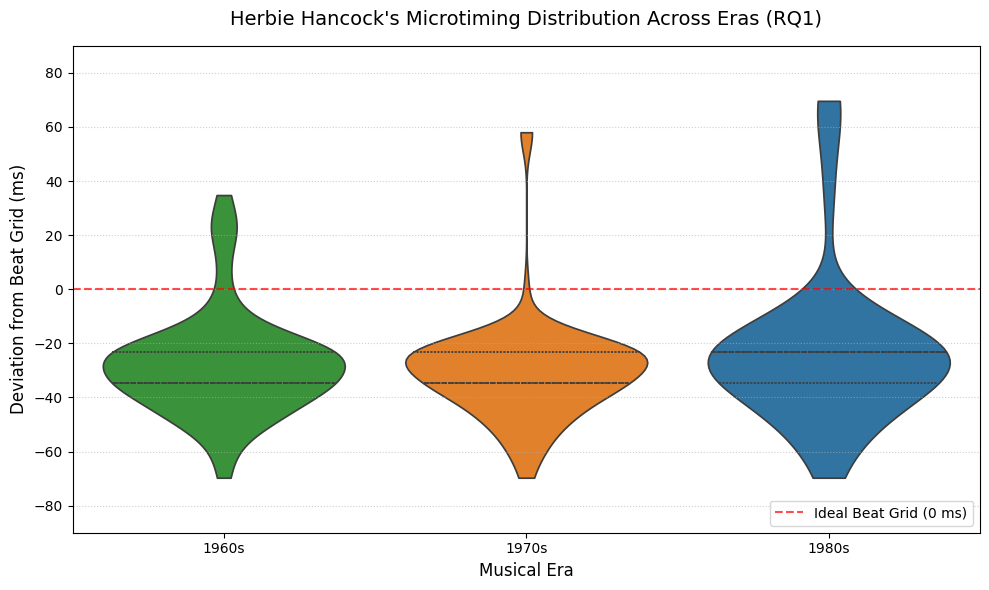

In [12]:
plt.figure(figsize=(10, 6))

palette = {'1960s': '#2ca02c', '1970s': '#ff7f0e', '1980s': '#1f77b4'}

sns.violinplot(
    order=['1960s','1970s','1980s'],
    x='Era', 
    y='Deviation', 
    data=df, 
    palette=palette, 
    inner='quartile',  # Показуємо медіану та квартилі всередині
    cut=0              # Обмежуємо малювання реальними краями значень
)

# Лінія ідеального рівного метронома (нуль)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Ideal Beat Grid (0 ms)')

plt.title("Herbie Hancock's Microtiming Distribution Across Eras (RQ1)", fontsize=14, pad=15)
plt.xlabel("Musical Era", fontsize=12)
plt.ylabel("Deviation from Beat Grid (ms)", fontsize=12)
plt.ylim(-90, 90)  # Співвідноситься з нашим лімітом у 120 мс
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../data/processed/microtiming_violin_plots.png', dpi=300)
plt.show()

## Interpretation

The following interpretations combine the observed statistical distributions with established stylistic characteristics of the selected recordings.

Several key observations emerge from the updated distribution plots ($\pm 80$ ms window):

- **Systematic Rushing (Ahead of the Beat):** Across all three recordings, the primary density of Hancock's note onsets is consistently shifted below the zero line (median deviations between **-20 ms and -35 ms**). This suggests a tendency toward a driving performance style, where note onsets are frequently positioned slightly ahead of the estimated beat grid.
- **1960s (Cantaloupe Island):** Displays a tight, highly concentrated core around -30 ms with a slight upper tail. This reflects a controlled, precise acoustic swing feel.
- **1970s (Chameleon):** Shows a slightly broader central distribution with a prominent upper spike, illustrating greater rhythmic elasticity and syncopated push typical of funk-fusion performance.
- **1980s (Rockit):** Shows a clean, unimodal distribution centered around -25 ms with an upper extension reaching towards +70 ms, representing tight interaction with programmed electronic rhythm tracks while maintaining human expression.

## Discussion

The obtained results support the hypothesis that expressive timing can be quantified using Music Information Retrieval techniques.

Rather than relying solely on subjective listening, microtiming distributions provide an objective description of performance style.

This approach demonstrates how computational methods can complement traditional musicological analysis by providing reproducible quantitative evidence.

The extracted timing profiles will later serve as the first component of the Groove Profile model developed in Phase 3.

Refining the tolerance window from $\pm 120$ ms to $\pm 80$ ms effectively removed off-beat sixteenth-note subdivisions that previously distorted the 1980s distribution into a bimodal shape. 

The refined distributions suggest a consistent tendency toward an ahead-of-the-beat timing bias within the selected corpus.

Although additional recordings would be required for broader generalization, the observed results demonstrate that computational analysis can reveal measurable stylistic characteristics of Hancock's performance practice.

## Conclusion

Phase 2 successfully transforms raw onset detections into quantitative descriptors of expressive timing.

The extracted microtiming features reveal measurable stylistic differences across the selected recordings and establish the first component of the computational Groove Profile.

In the following phase, these timing descriptors will be combined with dynamic and spectral features to construct a more comprehensive representation of Herbie Hancock's performance style.